# Explore Dataset + Mask Collator

Pulls a shard from R2, wires it through `make_dataset` + `MaskCollator`, then visualizes a clip and its V-JEPA encoder mask.

In [134]:
import io
import os
import tempfile

import boto3
import numpy as np
import torch
from dotenv import load_dotenv
from IPython.display import Image as IPyImage
from PIL import Image as PILImage
from torch.utils.data import DataLoader

from agent_1.data.dataset import make_dataset
from agent_1.models.vjepa.mask import MaskCollator

load_dotenv()

True

In [135]:
BUCKET_NAME = "datasets"  # <-- set me
PREFIX = "vision_encoder/DMG/longplays/"

# Clip / patch geometry — must match the encoder's patch_dim.
# Game Boy frames are 160 wide x 144 tall, so H=144, W=160.
CLIP_T, CLIP_H, CLIP_W = 16, 144, 160
PATCH_T, PATCH_H, PATCH_W = 2, 16, 16
GRID_SIZE = (CLIP_T // PATCH_T, CLIP_H // PATCH_H, CLIP_W // PATCH_W)

MASK_CONFIGS = [
    {"grid_size": GRID_SIZE, "mask_area_ratio": 0.4, "mask_ar_range": (0.75, 1.5), "num_sub_masks": 1},
    {"grid_size": GRID_SIZE, "mask_area_ratio": 0.15, "mask_ar_range": (0.75, 1.5), "num_sub_masks": 3},
]

BATCH_SIZE = 4
GRID_SIZE

(8, 9, 10)

In [136]:
s3 = boto3.client(
    "s3",
    endpoint_url=os.environ["R2_ENDPOINT_URL"],
    aws_access_key_id=os.environ["R2_ACCESS_KEY_ID"],
    aws_secret_access_key=os.environ["R2_SECRET_ACCESS_KEY"],
)

resp = s3.list_objects_v2(Bucket=BUCKET_NAME, Prefix=PREFIX, MaxKeys=1)
shard_key = resp["Contents"][0]["Key"]

tmp = tempfile.NamedTemporaryFile(suffix=".tar", delete=False)
s3.download_file(BUCKET_NAME, shard_key, tmp.name)
print(f"Downloaded {shard_key} -> {tmp.name}")

Downloaded vision_encoder/DMG/longplays/000000.tar -> /var/folders/st/4tnj9mbs1_z44dqyd8cyxnt00000gn/T/tmp4gaihvs8.tar


In [137]:
dataset = make_dataset(tmp.name, shuffle_buffer=0, shardshuffle=False)
collator = MaskCollator(MASK_CONFIGS)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, collate_fn=collator)

batch = next(iter(loader))
print({k: (v.shape if torch.is_tensor(v) else type(v).__name__) for k, v in batch.items() if k not in ("masks_enc", "masks_pred")})
for i, (me, mp) in enumerate(zip(batch["masks_enc"], batch["masks_pred"])):
    print(f"cfg {i}: masks_enc {tuple(me.shape)}  masks_pred {tuple(mp.shape)}")

{'video': torch.Size([4, 16, 1, 144, 160]), 'source_video': 'list', 'clip_number': torch.Size([4]), 'start_frame': torch.Size([4]), 'end_frame': torch.Size([4]), '__key__': 'list'}
cfg 0: masks_enc (4, 432)  masks_pred (4, 288)
cfg 1: masks_enc (4, 432)  masks_pred (4, 216)


## View a clip

Each clip is `(T, C, H, W)`. Display all `T` frames as a horizontal strip.

Pokémon_Red clip 101846


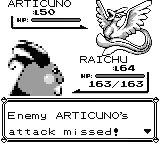

In [138]:
SAMPLE_IDX = 0
MASK_CFG_IDX = 0
FRAME_MS = 100  # ms per frame in the GIF

clip = batch["video"][SAMPLE_IDX]  # (T, C, H, W) uint8
frames = clip.squeeze(1).cpu().numpy()  # (T, H, W) for grayscale

print(f"{batch['source_video'][SAMPLE_IDX]} clip {batch['clip_number'][SAMPLE_IDX].item()}")

images = [PILImage.fromarray(f) for f in frames]
buf = io.BytesIO()
images[0].save(buf, format="GIF", save_all=True, append_images=images[1:], duration=FRAME_MS, loop=0)
IPyImage(data=buf.getvalue())

## View the mask for the clip

`masks_enc[cfg]` holds the patch indices the encoder *keeps*. Build a `(T_p, H_p, W_p)` binary grid, upsample to pixel space via `repeat_interleave`, then dim the masked-out (predictor target) regions of the clip.

cfg 0: kept 432/720 patches (60%)  —  top: raw, bottom: encoder view


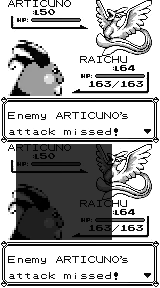

In [139]:
T_p, H_p, W_p = GRID_SIZE
num_patches = T_p * H_p * W_p

enc_idx = batch["masks_enc"][MASK_CFG_IDX][SAMPLE_IDX]
keep = torch.zeros(num_patches, dtype=torch.float32)
keep[enc_idx] = 1.0
keep = keep.view(T_p, H_p, W_p)

# upsample patch grid -> pixel grid
pixel_mask = (
    keep.repeat_interleave(PATCH_T, dim=0)
        .repeat_interleave(PATCH_H, dim=1)
        .repeat_interleave(PATCH_W, dim=2)
).numpy()  # (T, H, W)

# dim masked-out patches so the encoder's view is what's bright
DIM = 0.2
alpha = DIM + (1.0 - DIM) * pixel_mask
masked_frames = (frames.astype(np.float32) * alpha).clip(0, 255).astype(np.uint8)

# stack raw (top) and encoder view (bottom) per frame
stacked = np.concatenate([frames, masked_frames], axis=1)  # (T, 2H, W)

kept = int(keep.sum().item())
print(f"cfg {MASK_CFG_IDX}: kept {kept}/{num_patches} patches ({kept / num_patches:.0%})  —  top: raw, bottom: encoder view")

images = [PILImage.fromarray(f) for f in stacked]
buf = io.BytesIO()
images[0].save(buf, format="GIF", save_all=True, append_images=images[1:], duration=FRAME_MS, loop=0)
IPyImage(data=buf.getvalue())